# EE446 - TinyML - Assignment 2

## Importing Libraries

In [65]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

## Reading Data

In [66]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [67]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [68]:
## INSERT YOUR CODE HERE ##
data = data.drop(columns=['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'])

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [69]:
## INSERT YOUR CODE HERE ##

In [70]:
data['attack'] = data['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [71]:
## INSERT YOUR CODE HERE ##
label_encoder = LabelEncoder()

for col in ['protocoltype', 'service', 'flag', 'attack']:
    data[col] = label_encoder.fit_transform(data[col])

In [72]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [73]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

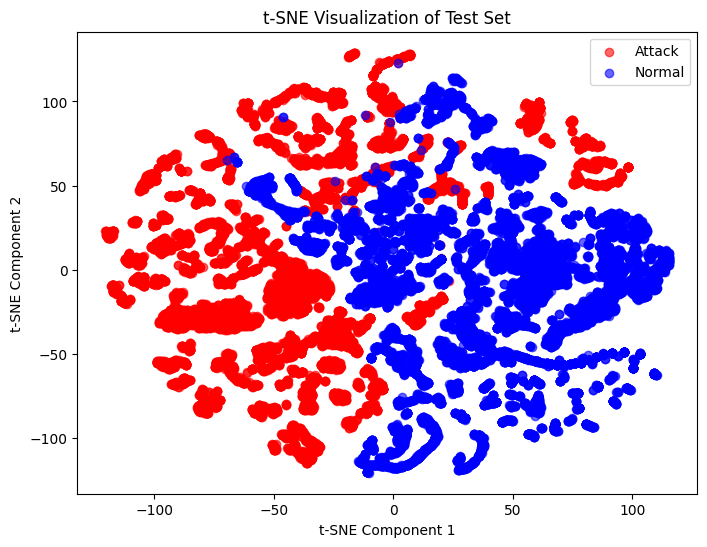

In [74]:
from sklearn.manifold import TSNE
## INSERT YOUR CODE HERE ##
tsne = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

y_test_1d = np.ravel(y_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_tsne[y_test_1d == 0, 0],
    X_test_tsne[y_test_1d == 0, 1],
    c='red',
    label='Attack',
    alpha=0.6
)

plt.scatter(
    X_test_tsne[y_test_1d == 1, 0],
    X_test_tsne[y_test_1d == 1, 1],
    c='blue',
    label='Normal',
    alpha=0.6
)

plt.title('t-SNE Visualization of Test Set')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

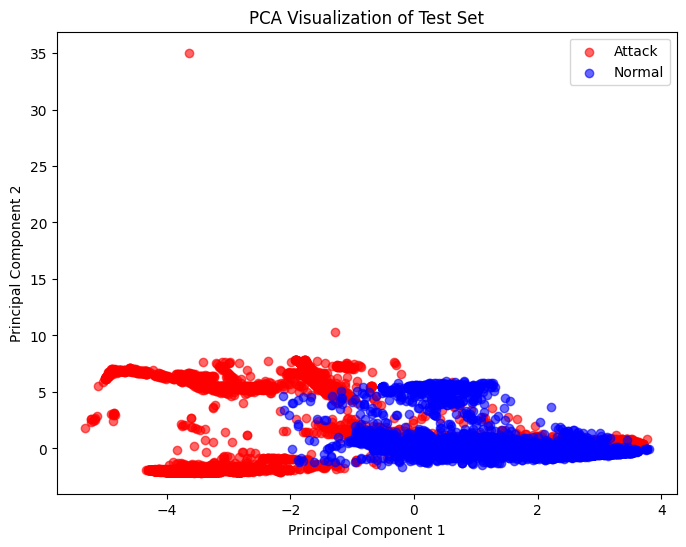

In [75]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

y_test_1d = np.ravel(y_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[y_test_1d == 0, 0],
    X_test_pca[y_test_1d == 0, 1],
    c='red',
    label='Attack',
    alpha=0.6
)

plt.scatter(
    X_test_pca[y_test_1d == 1, 0],
    X_test_pca[y_test_1d == 1, 1],
    c='blue',
    label='Normal',
    alpha=0.6
)

plt.title('PCA Visualization of Test Set')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

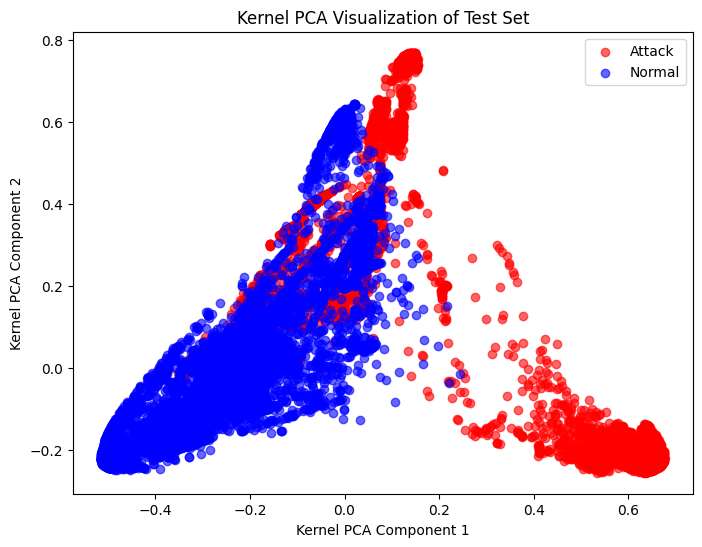

In [76]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##
kpca = KernelPCA(n_components=2, kernel='rbf')
X_test_kpca = kpca.fit_transform(X_test)

y_test_1d = np.ravel(y_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_kpca[y_test_1d == 0, 0],
    X_test_kpca[y_test_1d == 0, 1],
    c='red',
    label='Attack',
    alpha=0.6
)

plt.scatter(
    X_test_kpca[y_test_1d == 1, 0],
    X_test_kpca[y_test_1d == 1, 1],
    c='blue',
    label='Normal',
    alpha=0.6
)

plt.title('Kernel PCA Visualization of Test Set')
plt.xlabel('Kernel PCA Component 1')
plt.ylabel('Kernel PCA Component 2')
plt.legend()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [77]:
# Define the DNN model
input_dim = X_train.shape[1]

base_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

base_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 64)                2496      
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 2)                 34        
                                                                 
Total params: 5138 (20.07 KB)
Trainable params: 5138 (20.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [78]:
## INSERT YOUR CODE HERE ##
y_train_1d = np.ravel(y_train)
y_test_1d = np.ravel(y_test)

base_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = base_model.fit(
    X_train,
    y_train_1d,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
2520/2520 [==============================] - 1s 451us/step - loss: 0.0283 - accuracy: 0.9916 - val_loss: 0.0101 - val_accuracy: 0.9964
Epoch 2/10
2520/2520 [==============================] - 1s 430us/step - loss: 0.0100 - accuracy: 0.9964 - val_loss: 0.0095 - val_accuracy: 0.9964
Epoch 3/10
2520/2520 [==============================] - 1s 432us/step - loss: 0.0090 - accuracy: 0.9970 - val_loss: 0.0083 - val_accuracy: 0.9965
Epoch 4/10
2520/2520 [==============================] - 1s 432us/step - loss: 0.0066 - accuracy: 0.9976 - val_loss: 0.0069 - val_accuracy: 0.9975
Epoch 5/10
2520/2520 [==============================] - 1s 434us/step - loss: 0.0057 - accuracy: 0.9979 - val_loss: 0.0082 - val_accuracy: 0.9972
Epoch 6/10
2520/2520 [==============================] - 1s 433us/step - loss: 0.0050 - accuracy: 0.9980 - val_loss: 0.0062 - val_accuracy: 0.9980
Epoch 7/10
2520/2520 [==============================] - 1s 433us/step - loss: 0.0047 - accuracy: 0.9981 - val_loss: 0.0077 -

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [79]:
## INSERT YOUR CODE HERE ##
y_test_1d = np.ravel(y_test)

y_pred_prob = base_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:")
print(classification_report(y_test_1d, y_pred, target_names=['Attack', 'Normal']))

print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred))

788/788 [==============================] - 0s 221us/step
Classification Report:
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11772
      Normal       1.00      1.00      1.00     13423

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[11755    17]
 [   28 13395]]


In [80]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [81]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Full Integer INT8 Quantization for TFLite Micro deployment
def representative_data_gen():
    # Use a subset of training data to calibrate the INT8 quantization ranges
    for i in range(min(500, len(X_train))):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Force full integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Force INT8 input and output, important for Arduino TFLite Micro
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

with open('tflite_quant_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("Full Integer INT8 Quantized TFLite model saved as tflite_quant_model.tflite")
print("Quantized model size:", len(tflite_quant_model), "bytes")

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp3kzl5qcx/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp3kzl5qcx/assets
2026-05-30 15:46:09.421682: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-30 15:46:09.421696: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-30 15:46:09.421787: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp3kzl5qcx
2026-05-30 15:46:09.422243: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-30 15:46:09.422248: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp3kzl5qcx
2026-05-30 15:46:09.423481: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-30 15:46:09.442480: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Full Integer INT8 Quantized TFLite model saved as tflite_quant_model.tflite
Quantized model size: 8552 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [82]:
import os

# Save the INT8 quantized model
with open('tflite_quant_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('tflite_quant_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"INT8 quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 98.04 KB
INT8 quantized model size: 8.35 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [83]:
## INSERT YOUR CODE HERE ##
# Load the INT8 quantized TFLite model into an interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:")
print(input_details)
print("Output details:")
print(output_details)

input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

y_test_1d = np.ravel(y_test)
tflite_predictions = []

for i in range(len(X_test)):
    input_data = X_test[i:i+1].astype(np.float32)

    # Quantize float input to int8
    input_data_int8 = input_data / input_scale + input_zero_point
    input_data_int8 = np.round(input_data_int8)
    input_data_int8 = np.clip(input_data_int8, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], input_data_int8)
    interpreter.invoke()

    output_data_int8 = interpreter.get_tensor(output_details[0]['index'])

    # Dequantize output back to float scores
    output_data = (output_data_int8.astype(np.float32) - output_zero_point) * output_scale

    predicted_class = np.argmax(output_data, axis=1)[0]
    tflite_predictions.append(predicted_class)

tflite_predictions = np.array(tflite_predictions)

print("Classification Report for Full Integer INT8 Quantized Model:")
print(classification_report(y_test_1d, tflite_predictions, target_names=['Attack', 'Normal']))

print("Confusion Matrix for Full Integer INT8 Quantized Model:")
print(confusion_matrix(y_test_1d, tflite_predictions))

Input details:
[{'name': 'serving_default_dense_8_input:0', 'index': 0, 'shape': array([ 1, 38], dtype=int32), 'shape_signature': array([-1, 38], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.08421023190021515, -53), 'quantization_parameters': {'scales': array([0.08421023], dtype=float32), 'zero_points': array([-53], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details:
[{'name': 'StatefulPartitionedCall:0', 'index': 13, 'shape': array([1, 2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Classification Report for Full Integer INT8 Quantized Model:
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11772
      Normal       1.00      1.

## Converting tflite_model to C and create the header file

In [84]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [85]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [86]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.00773191865123693, -0.0044847000590822255, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6995794866568942, -0.32680812408381416, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, 1.2135880944209492, 1.021852715020502, 
    -0.3861460041139426, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922321

In [87]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 1, 1, 0, 1
};



In [88]:
# Generate 10 samples excluding the first five samples
Xtest_10 = X_test[5:15, :]
ytest_10 = y_test[5:15].reshape(-1)

print(c_writer.create_array(Xtest_10, "float", "X_test"))
print(c_writer.create_array(ytest_10, "uint8_t", "y_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.007725104698578091, -0.003625515164159388, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6384484682501711, 0.0862127650466973, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.028178668028642773, 
    0.7343425609306344, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922